In [28]:
#importing and reading the data
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import pandas as pd
df= pd.read_csv("/content/drive/MyDrive/IPL (2).csv")

Mounted at /content/drive


/tmp/ipykernel_1046/916756516.py:5: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("/content/drive/MyDrive/IPL (2).csv")


In [29]:
df.info()
#checking the null values in the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  object 
 3   match_type         283678 non-null  object 
 4   event_name         283678 non-null  object 
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  object 
 7   bowling_team       283678 non-null  object 
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  object 
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  object 
 16  va

In [30]:
df = df.drop(columns=['review_batter', 'team_reviewed', 'review_decision', 'umpire'], errors='ignore')
df.info()
#dropping some columns not required for the tests.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 61 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  object 
 3   match_type         283678 non-null  object 
 4   event_name         283678 non-null  object 
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  object 
 7   bowling_team       283678 non-null  object 
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  object 
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  object 
 16  va

In [31]:
df = df.drop(columns=['Unnamed: 0','event_name',
    'ball', 'ball_no', 'valid_ball',
    'runs_not_boundary',
    'non_striker', 'non_striker_pos',
    'umpires_call',
    'balls_per_over',
    'superover_winner', 'result_type', 'method' 'batter', 'bowler', 'bat_pos', 'balls_faced', 'runs_batter', 'runs_bowler','new_batter', 'next_batter', 'striker_out','batting_partners', 'batter_runs', 'batter_balls','bowler_wicket', 'extra_type', 'fielders', 'wicket_kind', 'player_out', 'event_match_no', 'match_number', 'day', 'month','gender', 'team_type', 'match_type'], errors='ignore')
df.info()
#some more columns not required

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           283678 non-null  int64  
 1   date               283678 non-null  object 
 2   innings            283678 non-null  int64  
 3   batting_team       283678 non-null  object 
 4   bowling_team       283678 non-null  object 
 5   over               283678 non-null  int64  
 6   batter             283678 non-null  object 
 7   runs_extras        283678 non-null  int64  
 8   runs_total         283678 non-null  int64  
 9   runs_target        136510 non-null  float64
 10  player_of_match    283678 non-null  object 
 11  match_won_by       283678 non-null  object 
 12  win_outcome        278954 non-null  object 
 13  toss_winner        283678 non-null  object 
 14  toss_decision      283678 non-null  object 
 15  venue              283678 non-null  object 
 16  ci

In [32]:
columnheads = df.columns.tolist()
for cols in columnheads:
  print(df[cols].describe() , "\n")
#checking all the columns individually to further clean inconsistent and missing data


count    2.836780e+05
mean     9.535684e+05
std      3.865091e+05
min      3.359820e+05
25%      5.483590e+05
50%      1.082612e+06
75%      1.304066e+06
max      1.529267e+06
Name: match_id, dtype: float64 

count         283678
unique           905
top       2020-10-18
freq             520
Name: date, dtype: object 

count    283678.000000
mean          1.482787
std           0.502511
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: innings, dtype: float64 

count             283678
unique                19
top       Mumbai Indians
freq               33892
Name: batting_team, dtype: object 

count             283678
unique                19
top       Mumbai Indians
freq               33981
Name: bowling_team, dtype: object 

count    283678.000000
mean          9.190833
std           5.680845
min           0.000000
25%           4.000000
50%           9.000000
75%          14.000000
max          19.000000
Name: o

In [33]:
#filling in the missing null values and changing datatype of obj to str
columnheads = df.columns.tolist()
for cols in columnheads:
  if(df[cols].dtype=='int64'or df[cols].dtype=='float64'):
    df[cols] = df[cols].fillna(df[cols].mean())
  if(df[cols].dtype=='object'):
    df[cols] = df[cols].fillna('none')
    df[cols] = df[cols].astype(str)
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           283678 non-null  int64  
 1   date               283678 non-null  object 
 2   innings            283678 non-null  int64  
 3   batting_team       283678 non-null  object 
 4   bowling_team       283678 non-null  object 
 5   over               283678 non-null  int64  
 6   batter             283678 non-null  object 
 7   runs_extras        283678 non-null  int64  
 8   runs_total         283678 non-null  int64  
 9   runs_target        283678 non-null  float64
 10  player_of_match    283678 non-null  object 
 11  match_won_by       283678 non-null  object 
 12  win_outcome        283678 non-null  object 
 13  toss_winner        283678 non-null  object 
 14  toss_decision      283678 non-null  object 
 15  venue              283678 non-null  object 
 16  ci

,0
match_id,0
date,0
innings,0
batting_team,0
bowling_team,0
over,0
batter,0
runs_extras,0
runs_total,0
runs_target,0


In [34]:
#checking the column unique values for inconsistent data
columnheads = df.columns.tolist()
for cols in columnheads:
  print(df[cols].unique())


[ 335982  335983  335984 ... 1529265 1529266 1529267]
['2008-04-18' '2008-04-19' '2008-04-20' '2008-04-21' '2008-04-22'
 '2008-04-23' '2008-04-24' '2008-04-25' '2008-04-26' '2008-04-27'
 '2008-04-28' '2008-04-29' '2008-04-30' '2008-05-01' '2008-05-02'
 '2008-05-03' '2008-05-04' '2008-05-05' '2008-05-06' '2008-05-07'
 '2008-05-08' '2008-05-09' '2008-05-10' '2008-05-11' '2008-05-12'
 '2008-05-13' '2008-05-14' '2008-05-15' '2008-05-16' '2008-05-17'
 '2008-05-18' '2008-05-19' '2008-05-20' '2008-05-21' '2008-05-23'
 '2008-05-24' '2008-05-25' '2008-05-26' '2008-05-27' '2008-05-28'
 '2008-05-30' '2008-05-31' '2008-06-01' '2009-04-18' '2009-04-19'
 '2009-04-20' '2009-04-21' '2009-04-22' '2009-04-23' '2009-04-24'
 '2009-04-25' '2009-04-26' '2009-04-27' '2009-04-28' '2009-04-29'
 '2009-04-30' '2009-05-01' '2009-05-02' '2009-05-03' '2009-05-04'
 '2009-05-05' '2009-05-06' '2009-05-07' '2009-05-08' '2009-05-09'
 '2009-05-10' '2009-05-11' '2009-05-12' '2009-05-13' '2009-05-14'
 '2009-05-15' '2009-05

In [35]:
#fixing inconsistent data
team_name_map = {
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

team_cols = ['toss_winner', 'win_outcome', 'batting_team', 'bowling_team','match_won_by']
for col in team_cols:
    df[col] = df[col].map(lambda x: team_name_map.get(x, x))

df['city'] = df['city'].map(lambda x: 'Bengaluru' if x == 'Bangalore' else x)


In [36]:
#dropping 2026 as its not required for the analysis
df = df[df['season'] != '2026']


In [37]:
#fixing more inconsistent data of the year column
df['season'] = df['season'].map(lambda x: {'2007/08': '2008', '2009/10': '2010', '2020/21': '2020'}.get(x, x))
df['year'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [38]:
#checking if the cleaning has worked
for col in ['batting_team', 'bowling_team', 'toss_winner', 'win_outcome', 'city', 'match_won_by']:
    print(f"\n{col}:")
    print(df[col].unique())



batting_team:
['Kolkata Knight Riders' 'Royal Challengers Bengaluru'
 'Chennai Super Kings' 'Punjab Kings' 'Rajasthan Royals' 'Delhi Capitals'
 'Mumbai Indians' 'Deccan Chargers' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Gujarat Lions'
 'Lucknow Super Giants' 'Gujarat Titans']

bowling_team:
['Royal Challengers Bengaluru' 'Kolkata Knight Riders' 'Punjab Kings'
 'Chennai Super Kings' 'Delhi Capitals' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Gujarat Lions'
 'Gujarat Titans' 'Lucknow Super Giants']

toss_winner:
['Royal Challengers Bengaluru' 'Chennai Super Kings' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Punjab Kings' 'Kolkata Knight Riders'
 'Delhi Capitals' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Gujarat Lions' 'Rising Pune Supergiant'
 'Gujarat Titans' 'Lucknow Super Giants']

win_outcome:
['140 runs' 

toss_won_match
True     591
False    578
Name: count, dtype: int64
Toss winner won the match: 50.5560%


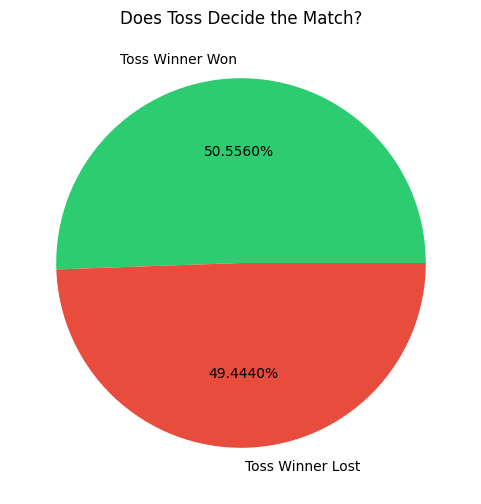

In [39]:
#solving part 1: does toss decide the game
match_df = df.drop_duplicates(subset='match_id').copy()

match_df['toss_won_match'] = match_df['toss_winner'] == match_df['match_won_by']

print(match_df['toss_won_match'].value_counts())
print(f"Toss winner won the match: {match_df['toss_won_match'].mean() * 100:.4f}%")

import matplotlib.pyplot as plt
import seaborn as sns
labels = ['Toss Winner Won', 'Toss Winner Lost']
sizes = match_df['toss_won_match'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.4f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Does Toss Decide the Match?')
plt.show()

home_team_won
True     381
False    344
Name: count, dtype: int64
Home team won: 52.5517%


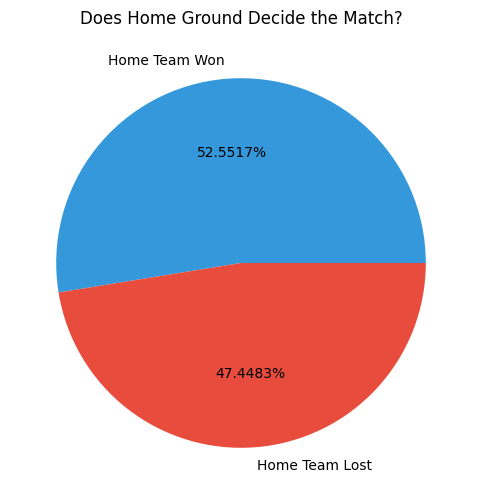

In [40]:
#solving part 2: does home ground matter in a game
home_city = {
    'Mumbai Indians': ['Mumbai', 'Navi Mumbai'],
    'Chennai Super Kings': ['Chennai', 'Ranchi'],
    'Kolkata Knight Riders': ['Kolkata'],
    'Royal Challengers Bengaluru': ['Bengaluru'],
    'Delhi Capitals': ['Delhi'],
    'Punjab Kings': ['Mohali', 'New Chandigarh', 'Indore'],
    'Rajasthan Royals': ['Jaipur', 'Guwahati'],
    'Sunrisers Hyderabad': ['Hyderabad'],
    'Gujarat Titans': ['Ahmedabad'],
    'Lucknow Super Giants': ['Lucknow'],
    'Deccan Chargers': ['Hyderabad'],
    'Kochi Tuskers Kerala': ['Kochi'],
    'Pune Warriors': ['Pune'],
    'Rising Pune Supergiant': ['Pune'],
    'Gujarat Lions': ['Rajkot']
}

match_df['batting_team_home'] = match_df.apply(
    lambda row: row['city'] in home_city.get(row['batting_team'], []), axis=1
)

match_df['bowling_team_home'] = match_df.apply(
    lambda row: row['city'] in home_city.get(row['bowling_team'], []), axis=1
)

match_df['is_home_game'] = match_df['batting_team_home'] | match_df['bowling_team_home']

match_df['home_team'] = match_df.apply(
    lambda row: row['batting_team'] if row['batting_team_home'] else row['bowling_team'], axis=1
)

home_games = match_df[match_df['is_home_game']].copy()
home_games['home_team_won'] = home_games['home_team'] == home_games['match_won_by']

print(home_games['home_team_won'].value_counts())
print(f"Home team won: {home_games['home_team_won'].mean() * 100:.4f}%")
labels = ['Home Team Won', 'Home Team Lost']
sizes = home_games['home_team_won'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.4f%%', colors=['#3498db', '#e74c3c'])
plt.title('Does Home Ground Decide the Match?')
plt.show()

/tmp/ipykernel_1046/1399208546.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top5_per_season = season_wins.groupby('season').apply(lambda x: x.nlargest(5, 'wins')).reset_index(drop=True)


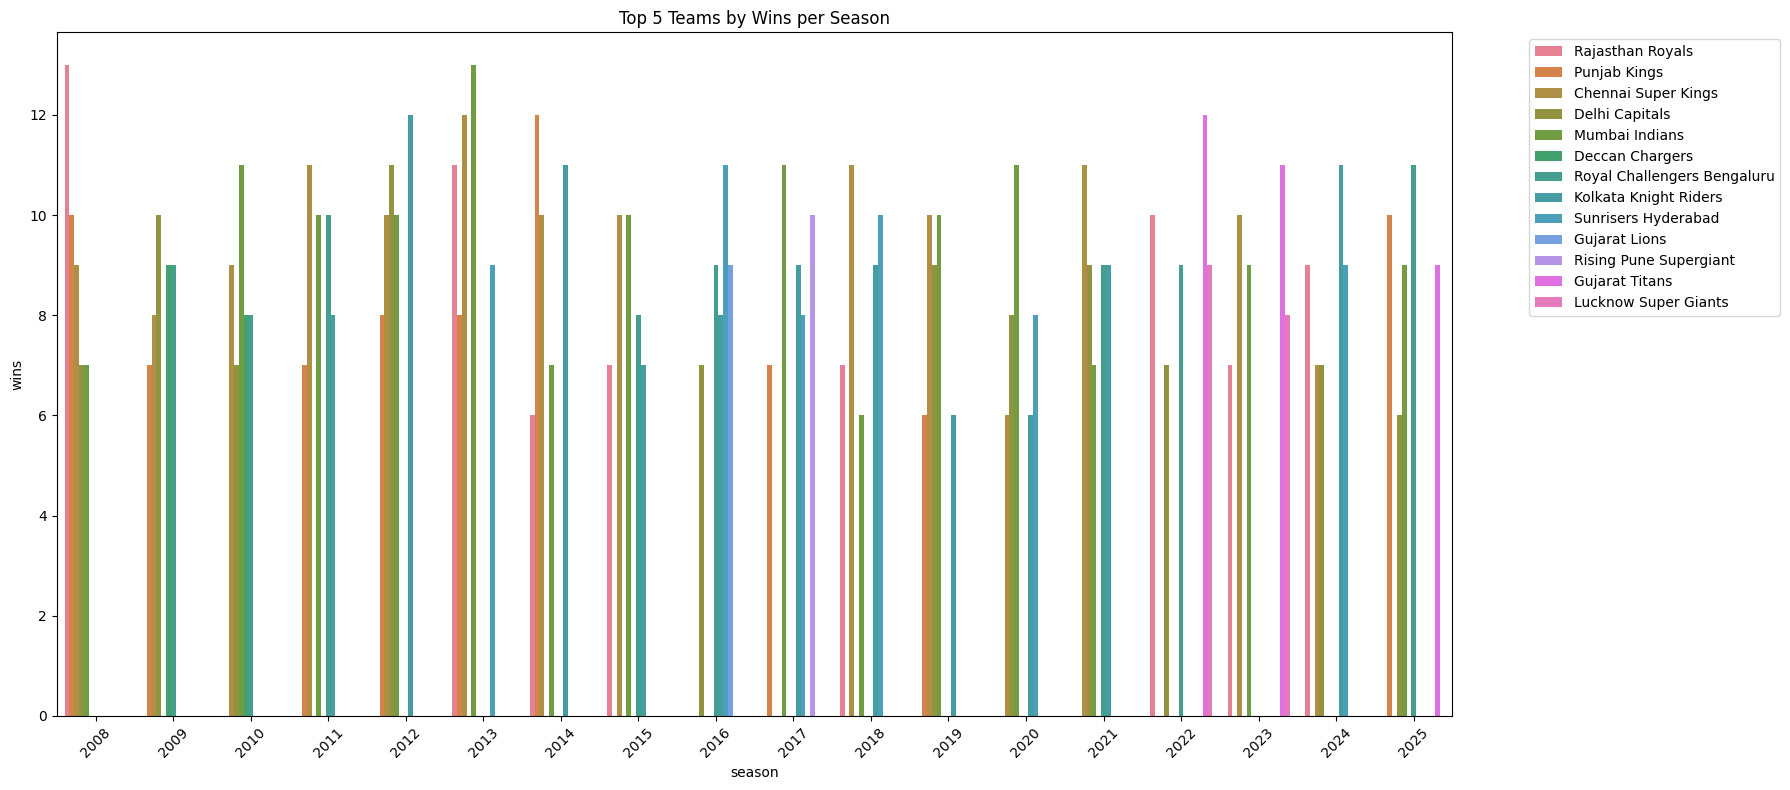

                       team  total_wins
             Mumbai Indians         151
        Chennai Super Kings         142
      Kolkata Knight Riders         135
Royal Challengers Bengaluru         132
               Punjab Kings         119
             Delhi Capitals         118
           Rajasthan Royals         114
        Sunrisers Hyderabad          93
             Gujarat Titans          37
       Lucknow Super Giants          30
            Deccan Chargers          29
                    Unknown          23
     Rising Pune Supergiant          15
              Gujarat Lions          13
              Pune Warriors          12
       Kochi Tuskers Kerala           6


In [41]:
#top 5 teams of each seasons and their win counts, also the overall top 5 teams of the IPL acc to wins
season_wins = match_df.groupby(['season', 'match_won_by']).size().reset_index(name='wins')
season_wins = season_wins[season_wins['match_won_by'] != 'none']
top5_per_season = season_wins.groupby('season').apply(lambda x: x.nlargest(5, 'wins')).reset_index(drop=True)


plt.figure(figsize=(18, 8))
sns.barplot(data=top5_per_season, x='season', y='wins', hue='match_won_by')
plt.title('Top 5 Teams by Wins per Season')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


overall_wins = season_wins.groupby('match_won_by')['wins'].sum().sort_values(ascending=False).reset_index()
overall_wins.columns = ['team', 'total_wins']
print(overall_wins.to_string(index=False))

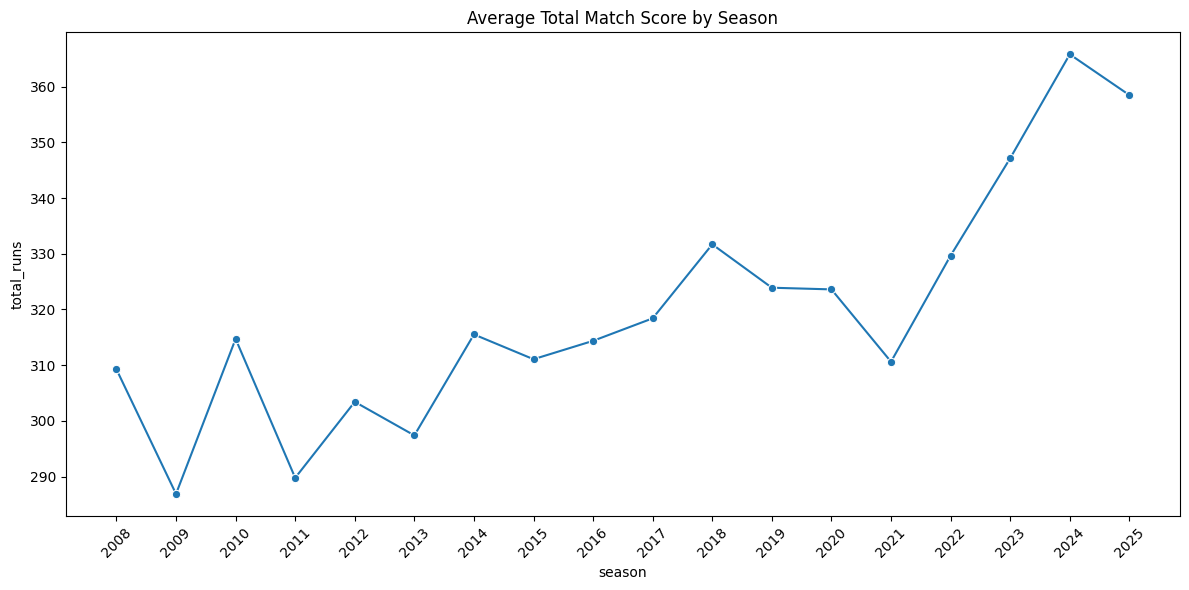

season  total_runs
  2008  309.258621
  2009  286.894737
  2010  314.716667
  2011  289.780822
  2012  303.418919
  2013  297.394737
  2014  315.516667
  2015  311.067797
  2016  314.366667
  2017  318.406780
  2018  331.683333
  2019  323.900000
  2020  323.600000
  2021  310.616667
  2022  329.662162
  2023  347.135135
  2024  365.788732
  2025  358.472973


In [42]:
# solving part 4: has overall runs scoring gotten easier in the IPL along the years
final_scores = df.groupby(['match_id', 'season', 'innings'])['team_runs'].max().reset_index()


match_totals = final_scores.groupby(['match_id', 'season'])['team_runs'].sum().reset_index()
match_totals.columns = ['match_id', 'season', 'total_runs']


avg_total = match_totals.groupby('season')['total_runs'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_total, x='season', y='total_runs', marker='o')
plt.title('Average Total Match Score by Season')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(avg_total.to_string(index=False))